# Grad-CAM Visualization for VGG16 Tuberculosis Classifier

This notebook generates Grad-CAM visualizations for the trained VGG16 tuberculosis classification model.

**Repository paths:**
- Trained model: `models/tb_vgg16_20epochs.h5`
- Dataset: `data/TB_Chest_Radiography_Database/`

Machine-specific Windows paths have been replaced with repository-relative paths for GitHub sharing.


Grad-CAM_TB

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Libraries loaded successfully.")

C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


TensorFlow version: 2.17.0
Libraries loaded successfully.


In [2]:
model = tf.keras.models.load_model(
    r"models/tb_vgg16_20epochs.h5"
)

print("Model loaded successfully.")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

Model loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 1)


In [3]:
base_model = model.layers[0]

print("Base model:", base_model.name)
print("Base model output shape:", base_model.output_shape)

Base model: vgg16
Base model output shape: (None, 7, 7, 512)


In [4]:
target_layer = base_model.get_layer("block5_conv3")

print("Grad-CAM layer:", target_layer.name)
print("Number of filters:", target_layer.filters)

Grad-CAM layer: block5_conv3
Number of filters: 512


In [5]:
def preprocess_image(path):
    img = tf.keras.preprocessing.image.load_img(
        path,
        target_size=(224, 224)
    )

    img = tf.keras.preprocessing.image.img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = img / 255.0

    return img

In [7]:
img_path = r"data/TB_Chest_Radiography_Database/Tuberculosis/TB.54.jpg"

img_array = preprocess_image(img_path)

print("Image prepared successfully.")
print("Image shape:", img_array.shape)
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())

Image prepared successfully.
Image shape: (1, 224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [8]:
prediction = model.predict(img_array, verbose=0)

probability = float(prediction[0][0])

print("Prediction probability:", probability)

if probability >= 0.5:
    predicted_class = "Tuberculosis"
else:
    predicted_class = "Normal"

print("Predicted class:", predicted_class)

Prediction probability: 1.0
Predicted class: Tuberculosis


In [9]:
def gradcam(img_array):

    # Create a model that returns:
    # 1. VGG16 target convolutional feature maps
    # 2. VGG16 feature output
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            target_layer.output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        # Forward pass through VGG16
        conv_outputs, base_output = grad_model(
            img_array,
            training=False
        )

        # Pass VGG16 features through the classification head
        x = base_output

        for layer in model.layers[1:]:
            x = layer(x, training=False)

        predictions = x[:, 0]

        # Explain the predicted class
        if float(predictions[0]) >= 0.5:
            target = predictions
        else:
            target = 1.0 - predictions

    # Calculate gradients
    grads = tape.gradient(
        target,
        conv_outputs
    )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps by their gradients
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize for visualization
    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

In [10]:
heatmap = gradcam(img_array)

print("Heatmap generated successfully.")
print("Heatmap shape:", heatmap.shape)
print("Heatmap minimum:", heatmap.min())
print("Heatmap maximum:", heatmap.max())

Heatmap generated successfully.
Heatmap shape: (14, 14)
Heatmap minimum: 0.0
Heatmap maximum: 0.0


In [11]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        target_layer.output,
        base_model.output
    ]
)

with tf.GradientTape() as tape:

    conv_outputs, base_output = grad_model(
        img_array,
        training=False
    )

    x = base_output

    for layer in model.layers[1:]:
        x = layer(x, training=False)

    predictions = x[:, 0]

    target = predictions

grads = tape.gradient(
    target,
    conv_outputs
)

print("Target layer output shape:", conv_outputs.shape)
print("Gradient shape:", grads.shape)

print("Prediction:", float(predictions[0]))

print("Gradient minimum:", float(tf.reduce_min(grads)))
print("Gradient maximum:", float(tf.reduce_max(grads)))

print("Gradient mean:", float(tf.reduce_mean(grads)))
print("Gradient absolute mean:", float(tf.reduce_mean(tf.abs(grads))))

Target layer output shape: (1, 14, 14, 512)
Gradient shape: (1, 14, 14, 512)
Prediction: 1.0
Gradient minimum: 0.0
Gradient maximum: 0.0
Gradient mean: 0.0
Gradient absolute mean: 0.0


In [15]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        target_layer.output,
        base_model.output
    ]
)

final_layer = model.layers[-1]

with tf.GradientTape() as tape:

    # Forward pass through VGG16
    conv_outputs, base_output = grad_model(
        img_array,
        training=False
    )

    # Classification head, excluding final sigmoid
    x = base_output

    for layer in model.layers[1:-1]:
        x = layer(x, training=False)

    # Calculate the pre-sigmoid logit directly
    weights, bias = final_layer.get_weights()

    logit = tf.matmul(
        x,
        tf.constant(weights, dtype=tf.float32)
    ) + tf.constant(bias, dtype=tf.float32)

    target = logit[:, 0]

# Calculate gradients of the logit
grads = tape.gradient(
    target,
    conv_outputs
)

print("Target layer output shape:", conv_outputs.shape)
print("Pre-sigmoid logit:", float(logit[0][0]))
print("Sigmoid probability:", float(tf.sigmoid(logit)[0][0]))

print("Gradient shape:", grads.shape)
print("Gradient minimum:", float(tf.reduce_min(grads)))
print("Gradient maximum:", float(tf.reduce_max(grads)))
print("Gradient mean:", float(tf.reduce_mean(grads)))
print("Gradient absolute mean:", float(tf.reduce_mean(tf.abs(grads))))

Target layer output shape: (1, 14, 14, 512)
Pre-sigmoid logit: 71.02141571044922
Sigmoid probability: 1.0
Gradient shape: (1, 14, 14, 512)
Gradient minimum: -0.06458843499422073
Gradient maximum: 0.08572844415903091
Gradient mean: 0.0009263285319320858
Gradient absolute mean: 0.002801881404593587


In [16]:
def gradcam_logit(img_array):

    # Create model for Grad-CAM
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            target_layer.output,
            base_model.output
        ]
    )

    final_layer = model.layers[-1]

    with tf.GradientTape() as tape:

        # Forward pass through VGG16
        conv_outputs, base_output = grad_model(
            img_array,
            training=False
        )

        # Forward pass through classifier
        x = base_output

        for layer in model.layers[1:-1]:
            x = layer(x, training=False)

        # Get final Dense layer weights
        weights, bias = final_layer.get_weights()

        # Calculate pre-sigmoid logit
        logit = tf.matmul(
            x,
            tf.constant(weights, dtype=tf.float32)
        ) + tf.constant(bias, dtype=tf.float32)

        target = logit[:, 0]

    # Calculate gradients
    grads = tape.gradient(
        target,
        conv_outputs
    )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weighted combination of feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Keep only positive contributions
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize for visualization
    max_val = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_val > 0,
        heatmap / max_val,
        tf.zeros_like(heatmap)
    )

    return heatmap.numpy()

In [17]:
heatmap = gradcam_logit(img_array)

print("Grad-CAM generated successfully.")
print("Heatmap shape:", heatmap.shape)
print("Heatmap minimum:", heatmap.min())
print("Heatmap maximum:", heatmap.max())
print("Heatmap mean:", heatmap.mean())

Grad-CAM generated successfully.
Heatmap shape: (14, 14)
Heatmap minimum: 0.0
Heatmap maximum: 1.0
Heatmap mean: 0.19079648


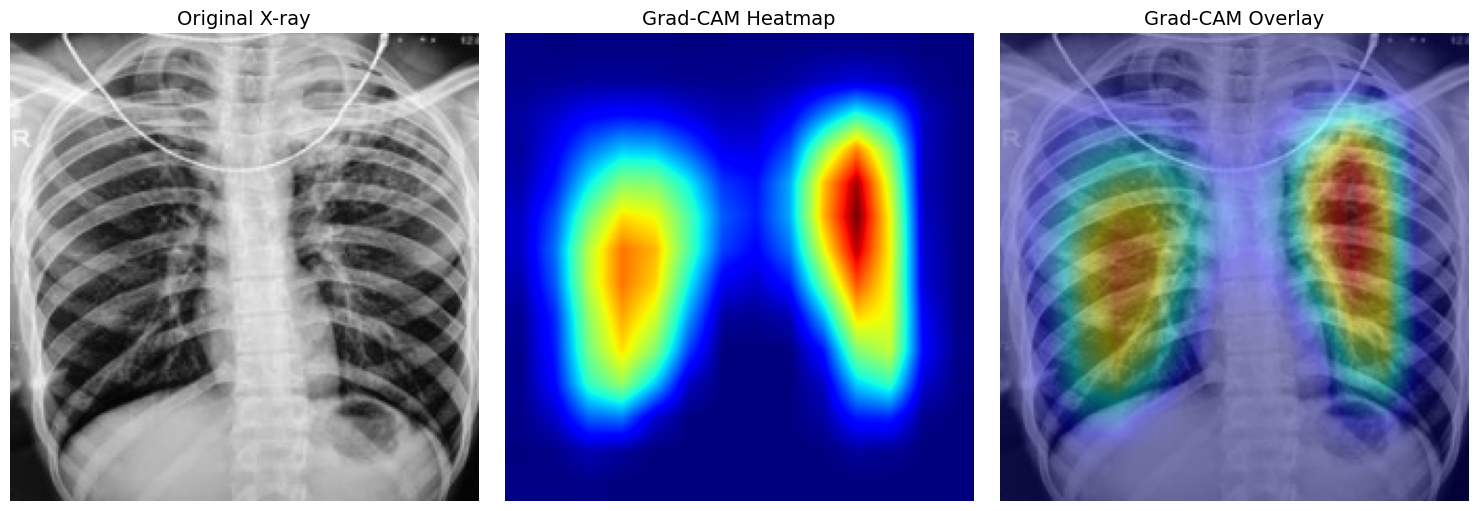

In [18]:
def show_gradcam(img_path, heatmap):

    # Load original X-ray
    original = cv2.imread(img_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    original = cv2.resize(original, (224, 224))

    # Resize Grad-CAM heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224),
        interpolation=cv2.INTER_LINEAR
    )

    # Convert heatmap to 8-bit
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    # Apply JET colormap
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Create overlay
    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # Create three-panel figure
    plt.figure(figsize=(15, 5))

    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original X-ray", fontsize=14)
    plt.axis("off")

    # Heatmap
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap", fontsize=14)
    plt.axis("off")

    # Overlay
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay", fontsize=14)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


show_gradcam(img_path, heatmap)

Grad-CAM_Normal

In [3]:
model = tf.keras.models.load_model(
    r"models/tb_vgg16_20epochs.h5"
)

print("Model loaded successfully.")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

Model loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 1)


In [4]:
base_model = model.layers[0]

print("Base model:", base_model.name)
print("Base model output shape:", base_model.output_shape)

Base model: vgg16
Base model output shape: (None, 7, 7, 512)


In [5]:
target_layer = base_model.get_layer("block5_conv3")

print("Grad-CAM layer:", target_layer.name)
print("Number of filters:", target_layer.filters)

Grad-CAM layer: block5_conv3
Number of filters: 512


In [6]:
def preprocess_image(path):
    img = tf.keras.preprocessing.image.load_img(
        path,
        target_size=(224, 224)
    )

    img = tf.keras.preprocessing.image.img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = img / 255.0

    return img

In [562]:
img_path = r"data/TB_Chest_Radiography_Database/Normal/Normal-1860.png"

img_array = preprocess_image(img_path)

print("Image prepared successfully.")
print("Image shape:", img_array.shape)
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())

Image prepared successfully.
Image shape: (1, 224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 0.98039216


In [563]:
prediction = model.predict(img_array, verbose=0)

probability = float(prediction[0][0])

print("Prediction probability:", probability)

if probability >= 0.5:
    predicted_class = "Tuberculosis"
else:
    predicted_class = "Normal"

print("Predicted class:", predicted_class)

Prediction probability: 9.360579152073445e-12
Predicted class: Normal


In [564]:
def gradcam(img_array):

    # Create a model that returns:
    # 1. VGG16 target convolutional feature maps
    # 2. VGG16 feature output
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            target_layer.output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        # Forward pass through VGG16
        conv_outputs, base_output = grad_model(
            img_array,
            training=False
        )

        # Pass VGG16 features through the classification head
        x = base_output

        for layer in model.layers[1:]:
            x = layer(x, training=False)

        predictions = x[:, 0]

        # Explain the predicted class
        if float(predictions[0]) >= 0.5:
            target = predictions
        else:
            target = 1.0 - predictions

    # Calculate gradients
    grads = tape.gradient(
        target,
        conv_outputs
    )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps by their gradients
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize for visualization
    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

In [565]:
heatmap = gradcam(img_array)

print("Heatmap generated successfully.")
print("Heatmap shape:", heatmap.shape)
print("Heatmap minimum:", heatmap.min())
print("Heatmap maximum:", heatmap.max())

Heatmap generated successfully.
Heatmap shape: (14, 14)
Heatmap minimum: 0.0
Heatmap maximum: 3.2106804e-05


In [566]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        target_layer.output,
        base_model.output
    ]
)

with tf.GradientTape() as tape:

    conv_outputs, base_output = grad_model(
        img_array,
        training=False
    )

    x = base_output

    for layer in model.layers[1:]:
        x = layer(x, training=False)

    predictions = x[:, 0]

    target = predictions

grads = tape.gradient(
    target,
    conv_outputs
)

print("Target layer output shape:", conv_outputs.shape)
print("Gradient shape:", grads.shape)

print("Prediction:", float(predictions[0]))

print("Gradient minimum:", float(tf.reduce_min(grads)))
print("Gradient maximum:", float(tf.reduce_max(grads)))

print("Gradient mean:", float(tf.reduce_mean(grads)))
print("Gradient absolute mean:", float(tf.reduce_mean(tf.abs(grads))))

Target layer output shape: (1, 14, 14, 512)
Gradient shape: (1, 14, 14, 512)
Prediction: 9.360578284711707e-12
Gradient minimum: -8.69980086234956e-13
Gradient maximum: 5.428338442810265e-13
Gradient mean: -5.8239766226883885e-15
Gradient absolute mean: 2.5259328862489022e-14


In [567]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        target_layer.output,
        base_model.output
    ]
)

final_layer = model.layers[-1]

with tf.GradientTape() as tape:

    # Forward pass through VGG16
    conv_outputs, base_output = grad_model(
        img_array,
        training=False
    )

    # Classification head, excluding final sigmoid
    x = base_output

    for layer in model.layers[1:-1]:
        x = layer(x, training=False)

    # Calculate the pre-sigmoid logit directly
    weights, bias = final_layer.get_weights()

    logit = tf.matmul(
        x,
        tf.constant(weights, dtype=tf.float32)
    ) + tf.constant(bias, dtype=tf.float32)

    target = logit[:, 0]

# Calculate gradients of the logit
grads = tape.gradient(
    target,
    conv_outputs
)

print("Target layer output shape:", conv_outputs.shape)
print("Pre-sigmoid logit:", float(logit[0][0]))
print("Sigmoid probability:", float(tf.sigmoid(logit)[0][0]))

print("Gradient shape:", grads.shape)
print("Gradient minimum:", float(tf.reduce_min(grads)))
print("Gradient maximum:", float(tf.reduce_max(grads)))
print("Gradient mean:", float(tf.reduce_mean(grads)))
print("Gradient absolute mean:", float(tf.reduce_mean(tf.abs(grads))))

Target layer output shape: (1, 14, 14, 512)
Pre-sigmoid logit: -25.394514083862305
Sigmoid probability: 9.360578284711707e-12
Gradient shape: (1, 14, 14, 512)
Gradient minimum: -0.09294085204601288
Gradient maximum: 0.05799148976802826
Gradient mean: -0.0006221813382580876
Gradient absolute mean: 0.002698479453101754


In [568]:
def gradcam_logit(img_array):

    # Create model for Grad-CAM
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            target_layer.output,
            base_model.output
        ]
    )

    final_layer = model.layers[-1]

    with tf.GradientTape() as tape:

        # Forward pass through VGG16
        conv_outputs, base_output = grad_model(
            img_array,
            training=False
        )

        # Forward pass through classifier
        x = base_output

        for layer in model.layers[1:-1]:
            x = layer(x, training=False)

        # Get final Dense layer weights
        weights, bias = final_layer.get_weights()

        # Calculate pre-sigmoid logit
        logit = tf.matmul(
            x,
            tf.constant(weights, dtype=tf.float32)
        ) + tf.constant(bias, dtype=tf.float32)

        target = logit[:, 0]

    # Calculate gradients
    grads = tape.gradient(
        target,
        conv_outputs
    )

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weighted combination of feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Keep only positive contributions
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize for visualization
    max_val = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_val > 0,
        heatmap / max_val,
        tf.zeros_like(heatmap)
    )

    return heatmap.numpy()

In [569]:
heatmap = gradcam_logit(img_array)

print("Grad-CAM generated successfully.")
print("Heatmap shape:", heatmap.shape)
print("Heatmap minimum:", heatmap.min())
print("Heatmap maximum:", heatmap.max())
print("Heatmap mean:", heatmap.mean())

Grad-CAM generated successfully.
Heatmap shape: (14, 14)
Heatmap minimum: 0.0
Heatmap maximum: 1.0
Heatmap mean: 0.016239166


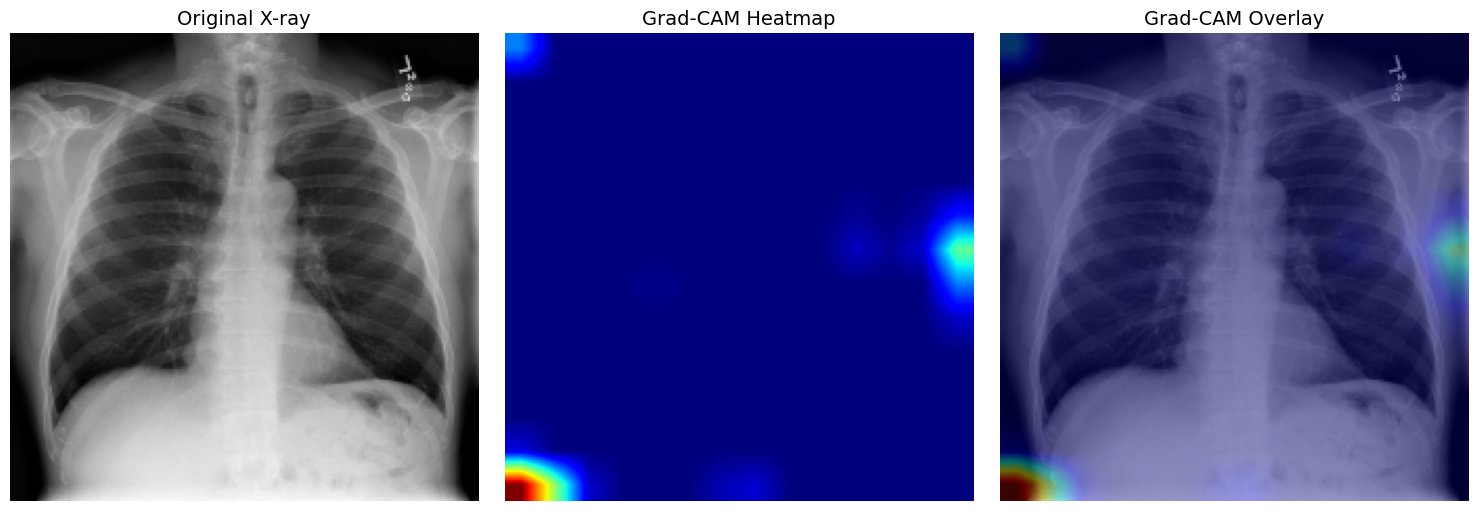

In [570]:
def show_gradcam(img_path, heatmap):

    # Load original X-ray
    original = cv2.imread(img_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    original = cv2.resize(original, (224, 224))

    # Resize Grad-CAM heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224),
        interpolation=cv2.INTER_LINEAR
    )

    # Convert heatmap to 8-bit
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    # Apply JET colormap
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Create overlay
    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # Create three-panel figure
    plt.figure(figsize=(15, 5))

    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original X-ray", fontsize=14)
    plt.axis("off")

    # Heatmap
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap", fontsize=14)
    plt.axis("off")

    # Overlay
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay", fontsize=14)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


show_gradcam(img_path, heatmap)